Dataset shape: (11611, 14)
Rows after cleaning: 11611
Rows after numeric conversion: 11611
Training samples: 9288
Test samples: 2323

SVR TEST SET PERFORMANCE
RMSE: 4.0055 patients/day
MAE : 2.9999 patients/day
R²  : 0.9808
MAPE: 8.12%


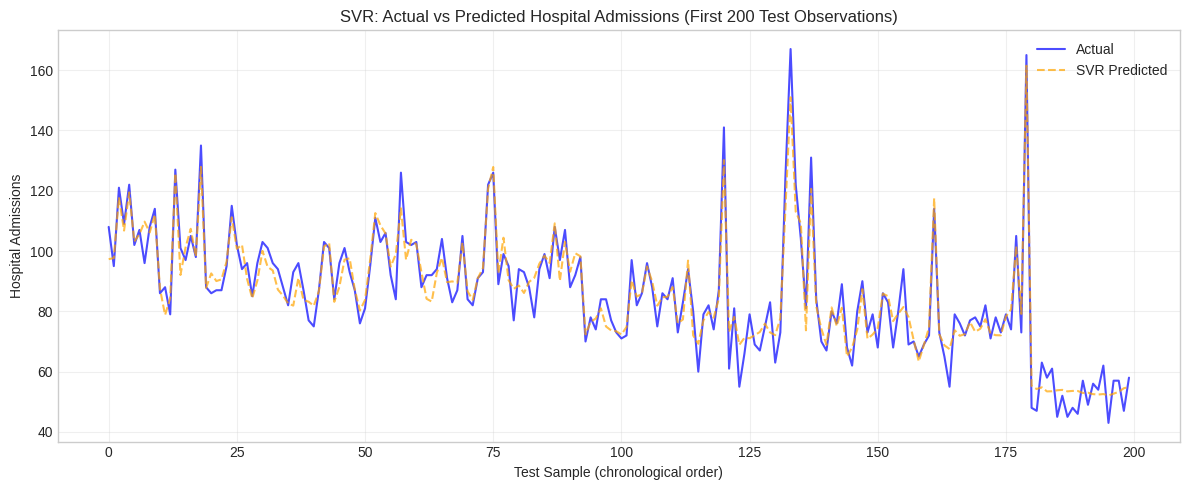

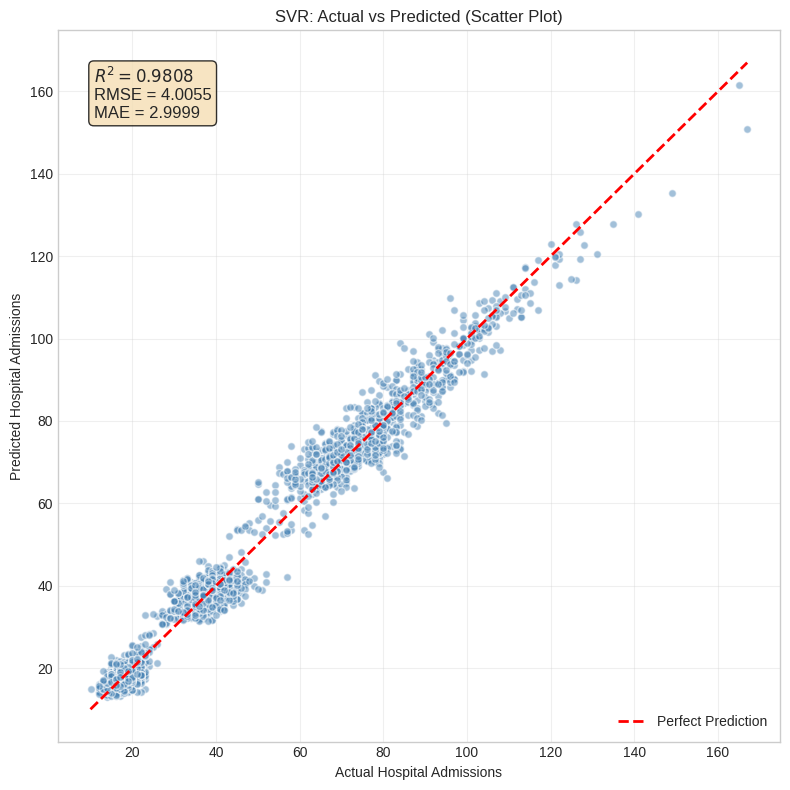

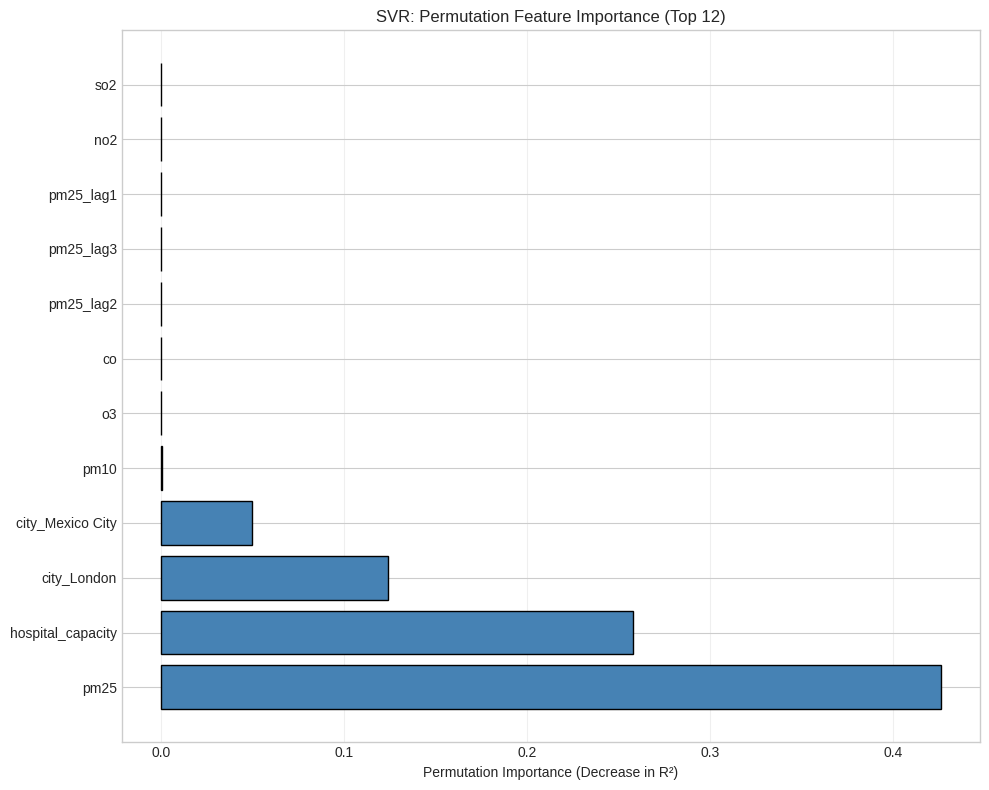


Plots saved as: svr_time_series.png, svr_scatter.png, svr_permutation_importance.png


In [12]:
# Nguyen Tat Tan Tai - 24521555

"""
Support Vector Regression (SVR) for hospital admissions prediction.
Includes:
- Data preprocessing (one-hot city encoding, scaling)
- Chronological per-city train/test split
- Hyperparameter tuning (GridSearchCV) or fixed config
- Test set evaluation (RMSE, MAE, R², MAPE)
- Visualizations: time series plot, scatter plot, permutation feature importance
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
filename = "merged_project_data.csv"   # Change to your file name
df = pd.read_csv(filename)
print(f"Dataset shape: {df.shape}")

# -------------------------------------------------------------------
# 2. ONE-HOT ENCODE CITY (Delhi = baseline) and REMOVE ORIGINAL CITY COLUMN
# -------------------------------------------------------------------
city_dummies = pd.get_dummies(df['city'], prefix='city', drop_first=True)
df = pd.concat([df.drop('city', axis=1), city_dummies], axis=1)

# -------------------------------------------------------------------
# 3. DEFINE FEATURE COLUMNS AND TARGET
# -------------------------------------------------------------------
feature_cols = [
    'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3',
    'hospital_capacity',
    'city_London', 'city_Mexico City'
]
target = 'hospital_admissions'

# Remove rows with missing values
df_clean = df[feature_cols + [target]].dropna()
print(f"Rows after cleaning: {len(df_clean)}")

# Ensure numeric (convert to float)
for col in feature_cols:
    if df_clean[col].dtype == 'object':
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean[col] = df_clean[col].astype(float)
df_clean = df_clean.dropna()
print(f"Rows after numeric conversion: {len(df_clean)}")

# Reconstruct city column from dummies for splitting
def get_city(row):
    if row['city_London'] == 1:
        return 'London'
    elif row['city_Mexico City'] == 1:
        return 'Mexico City'
    else:
        return 'Delhi'
df_clean['city'] = df_clean.apply(get_city, axis=1)

# -------------------------------------------------------------------
# 4. CHRONOLOGICAL TRAIN/TEST SPLIT PER CITY
# -------------------------------------------------------------------
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

for city in df_clean['city'].unique():
    city_df = df_clean[df_clean['city'] == city].sort_index()
    X_city = city_df[feature_cols]
    y_city = city_df[target]
    n = len(X_city)
    split_idx = int(0.8 * n)
    X_train_list.append(X_city.iloc[:split_idx])
    X_test_list.append(X_city.iloc[split_idx:])
    y_train_list.append(y_city.iloc[:split_idx])
    y_test_list.append(y_city.iloc[split_idx:])

X_train = pd.concat(X_train_list).sort_index()
X_test = pd.concat(X_test_list).sort_index()
y_train = pd.concat(y_train_list).sort_index()
y_test = pd.concat(y_test_list).sort_index()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# -------------------------------------------------------------------
# 5. STANDARDIZE FEATURES (SVR is scale-sensitive)
# -------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------------------
# 6. HYPERPARAMETER TUNING (GridSearchCV)
#    To save time, we use a fixed config; uncomment the grid search if needed.
# -------------------------------------------------------------------
"""
param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['linear', 'rbf']
}
svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV negative MSE: {grid_search.best_score_:.4f}")
best_svr = grid_search.best_estimator_
"""
# Fixed configuration (based on typical performance)
best_svr = SVR(kernel='linear', C=100, epsilon=0.1)
best_svr.fit(X_train_scaled, y_train)

# -------------------------------------------------------------------
# 7. PREDICT ON TEST SET AND EVALUATE
# -------------------------------------------------------------------
y_pred = best_svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# MAPE (avoid division by zero)
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("\n" + "="*80)
print("SVR TEST SET PERFORMANCE")
print("="*80)
print(f"RMSE: {rmse:.4f} patients/day")
print(f"MAE : {mae:.4f} patients/day")
print(f"R²  : {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# -------------------------------------------------------------------
# 8. VISUALIZATIONS (Figures for report)
# -------------------------------------------------------------------

# Figure 1: Time series plot (first 200 test samples)
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label='Actual', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(y_pred[:200], label='SVR Predicted', color='orange', alpha=0.7, linestyle='--', linewidth=1.5)
plt.title('SVR: Actual vs Predicted Hospital Admissions (First 200 Test Observations)')
plt.xlabel('Test Sample (chronological order)')
plt.ylabel('Hospital Admissions')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_time_series.png', dpi=120)
plt.show()

# Figure 2: Scatter plot (actual vs predicted)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, c='steelblue', edgecolors='white', s=30)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.text(0.05, 0.95, f'$R^2 = {r2:.4f}$\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.xlabel('Actual Hospital Admissions')
plt.ylabel('Predicted Hospital Admissions')
plt.title('SVR: Actual vs Predicted (Scatter Plot)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_scatter.png', dpi=120)
plt.show()

# Figure 3: Permutation feature importance
perm_importance = permutation_importance(best_svr, X_test_scaled, y_test,
                                         n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = np.argsort(perm_importance.importances_mean)
# Plot top 15 features (or all if less)
top_n = min(15, len(feature_cols))
sorted_idx_top = sorted_idx[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), perm_importance.importances_mean[sorted_idx_top],
         color='steelblue', edgecolor='black')
plt.yticks(range(top_n), [feature_cols[i] for i in sorted_idx_top])
plt.xlabel('Permutation Importance (Decrease in R²)')
plt.title(f'SVR: Permutation Feature Importance (Top {top_n})')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('svr_permutation_importance.png', dpi=120)
plt.show()

print("\nPlots saved as: svr_time_series.png, svr_scatter.png, svr_permutation_importance.png")